In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

print("Orbital Mechanics Lab initialized.")

Orbital Mechanics Lab initialized.


In [ ]:
# ============================================
# EARTH CONSTANTS
# ============================================

MU_EARTH = 398600.4418      # km^3 / s^2
R_EARTH = 6378.137          # km
M_EARTH = 5.97219e24        # kg
G = 6.67430e-20             # km^3 / kg / s^2

print("Earth gravitational parameter μ =", MU_EARTH, "km^3/s^2")
print("Earth radius =", R_EARTH, "km")
print("Earth mass =", M_EARTH, "kg")

Earth gravitational parameter μ = 398600.4418 km^3/s^2
Earth radius = 6378.137 km
Earth mass = 5.97219e+24 kg


In [ ]:
# ============================================
# NEWTONIAN GRAVITY
# ============================================

def gravitational_force(mass_object, distance):
    """
    Calculate gravitational force.

    mass_object : kg
    distance    : km

    Returns:
        force in Newtons
    """

    G_SI = 6.67430e-11       # m^3 kg^-1 s^-2
    M = 5.97219e24           # kg

    distance_m = distance * 1000

    F = G_SI * M * mass_object / distance_m**2

    return F


satellite_mass = 1000       # kg
altitude = 400              # km

distance = R_EARTH + altitude

force = gravitational_force(
    satellite_mass,
    distance
)

print(f"Satellite altitude: {altitude} km")
print(f"Distance from Earth's center: {distance:.2f} km")
print(f"Gravitational force: {force:.2f} N")

Satellite altitude: 400 km
Distance from Earth's center: 6778.14 km
Gravitational force: 8675.98 N


In [ ]:
# ============================================
# GRAVITATIONAL ACCELERATION
# ============================================

def gravitational_acceleration(r):
    """
    Gravitational acceleration.

    r: distance from Earth's center in km

    Returns:
        acceleration in km/s^2
    """

    return MU_EARTH / r**2


acceleration = gravitational_acceleration(distance)

print(f"Gravitational acceleration: {acceleration:.6f} km/s²")
print(f"Gravitational acceleration: {acceleration * 1000:.4f} m/s²")

Gravitational acceleration: 0.008676 km/s²
Gravitational acceleration: 8.6760 m/s²


In [ ]:
# ============================================
# CIRCULAR ORBITAL VELOCITY
# ============================================

def circular_orbital_velocity(r):
    """
    Circular orbital velocity.

    r: km

    Returns:
        velocity in km/s
    """

    return np.sqrt(MU_EARTH / r)


velocity = circular_orbital_velocity(distance)

print(f"Altitude: {altitude} km")
print(f"Orbital velocity: {velocity:.4f} km/s")
print(f"Orbital velocity: {velocity * 1000:.2f} m/s")

Altitude: 400 km
Orbital velocity: 7.6686 km/s
Orbital velocity: 7668.56 m/s


In [ ]:
# ============================================
# ESCAPE VELOCITY
# ============================================

def escape_velocity(r):
    return np.sqrt(2 * MU_EARTH / r)


v_escape = escape_velocity(distance)

print(f"Orbital velocity : {velocity:.4f} km/s")
print(f"Escape velocity  : {v_escape:.4f} km/s")

print()
print("Ratio:")
print(v_escape / velocity)

Orbital velocity : 7.6686 km/s
Escape velocity  : 10.8450 km/s

Ratio:
1.414213562373095


In [ ]:
# ============================================
# ORBITAL PERIOD
# ============================================

def orbital_period(r):
    """
    Orbital period for circular orbit.

    Returns:
        seconds
    """

    return 2 * np.pi * np.sqrt(r**3 / MU_EARTH)


period_seconds = orbital_period(distance)

period_minutes = period_seconds / 60
period_hours = period_minutes / 60

print(f"Orbital period: {period_seconds:.2f} seconds")
print(f"Orbital period: {period_minutes:.2f} minutes")
print(f"Orbital period: {period_hours:.2f} hours")

Orbital period: 5553.62 seconds
Orbital period: 92.56 minutes
Orbital period: 1.54 hours


In [ ]:
# ============================================
# ORBITAL CALCULATOR
# ============================================

def orbital_calculator(altitude_km):

    r = R_EARTH + altitude_km

    velocity = np.sqrt(MU_EARTH / r)

    escape = np.sqrt(2 * MU_EARTH / r)

    period = 2 * np.pi * np.sqrt(r**3 / MU_EARTH)

    gravity = MU_EARTH / r**2

    return {
        "altitude_km": altitude_km,
        "radius_km": r,
        "velocity_km_s": velocity,
        "escape_velocity_km_s": escape,
        "gravity_km_s2": gravity,
        "period_seconds": period,
        "period_minutes": period / 60,
        "period_hours": period / 3600
    }


result = orbital_calculator(400)

for key, value in result.items():
    print(f"{key}: {value}")

altitude_km: 400
radius_km: 6778.137
velocity_km_s: 7.668558175407055
escape_velocity_km_s: 10.844978975507733
gravity_km_s2: 0.008675951000931728
period_seconds: 5553.624271252228
period_minutes: 92.56040452087046
period_hours: 1.5426734086811744


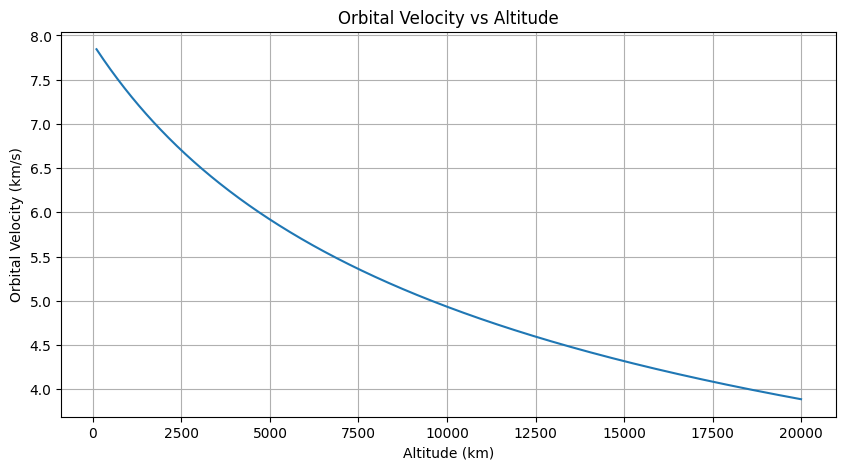

In [ ]:
# ============================================
# ORBITAL VELOCITY VS ALTITUDE
# ============================================

altitudes = np.linspace(100, 20000, 500)

radii = R_EARTH + altitudes

velocities = np.sqrt(MU_EARTH / radii)

plt.figure(figsize=(10, 5))

plt.plot(altitudes, velocities)

plt.xlabel("Altitude (km)")
plt.ylabel("Orbital Velocity (km/s)")
plt.title("Orbital Velocity vs Altitude")

plt.grid(True)
plt.show()

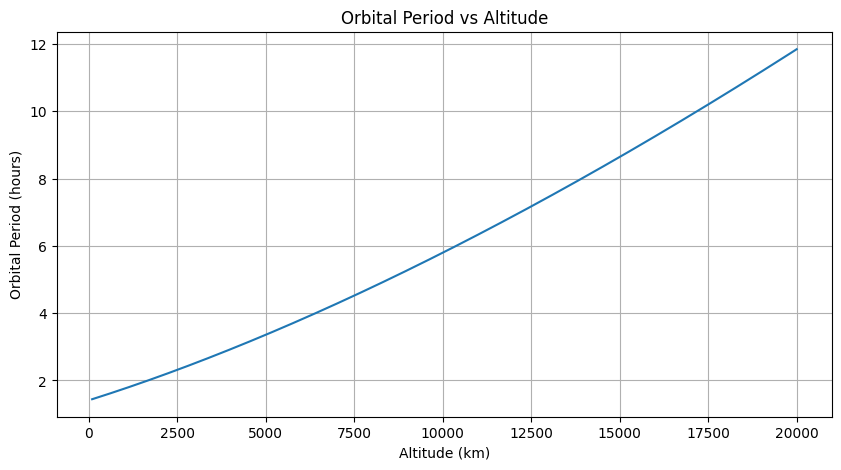

In [ ]:
# ============================================
# ORBITAL PERIOD VS ALTITUDE
# ============================================

periods = 2 * np.pi * np.sqrt(radii**3 / MU_EARTH)

periods_hours = periods / 3600

plt.figure(figsize=(10, 5))

plt.plot(altitudes, periods_hours)

plt.xlabel("Altitude (km)")
plt.ylabel("Orbital Period (hours)")
plt.title("Orbital Period vs Altitude")

plt.grid(True)
plt.show()

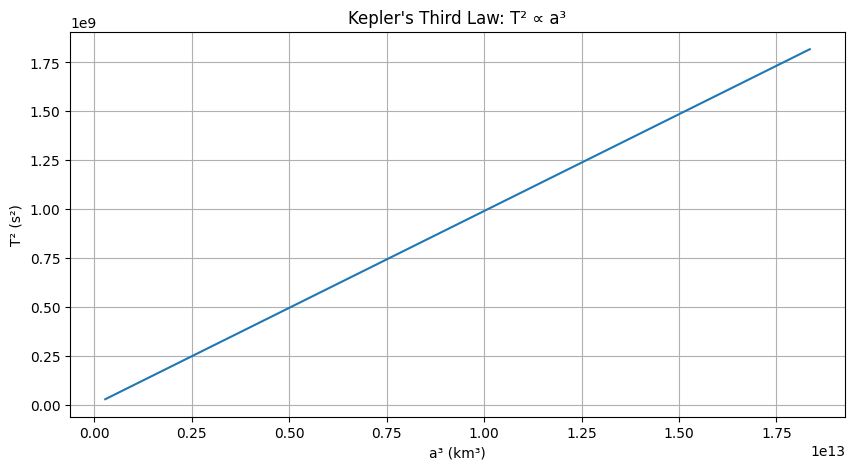

In [ ]:
# ============================================
# KEPLER'S THIRD LAW
# ============================================

a = np.linspace(R_EARTH + 200, R_EARTH + 20000, 300)

T = 2 * np.pi * np.sqrt(a**3 / MU_EARTH)

T2 = T**2
a3 = a**3

plt.figure(figsize=(10, 5))

plt.plot(a3, T2)

plt.xlabel("a³ (km³)")
plt.ylabel("T² (s²)")
plt.title("Kepler's Third Law: T² ∝ a³")

plt.grid(True)
plt.show()

In [ ]:
# ============================================
# ORBITAL ELEMENTS
# ============================================

orbital_elements = {
    "semi_major_axis_a_km": 6778.137,
    "eccentricity_e": 0.001,
    "inclination_i_deg": 35.0,
    "RAAN_Omega_deg": 40.0,
    "argument_of_perigee_omega_deg": 20.0,
    "true_anomaly_nu_deg": 0.0
}

for element, value in orbital_elements.items():
    print(f"{element}: {value}")

semi_major_axis_a_km: 6778.137
eccentricity_e: 0.001
inclination_i_deg: 35.0
RAAN_Omega_deg: 40.0
argument_of_perigee_omega_deg: 20.0
true_anomaly_nu_deg: 0.0


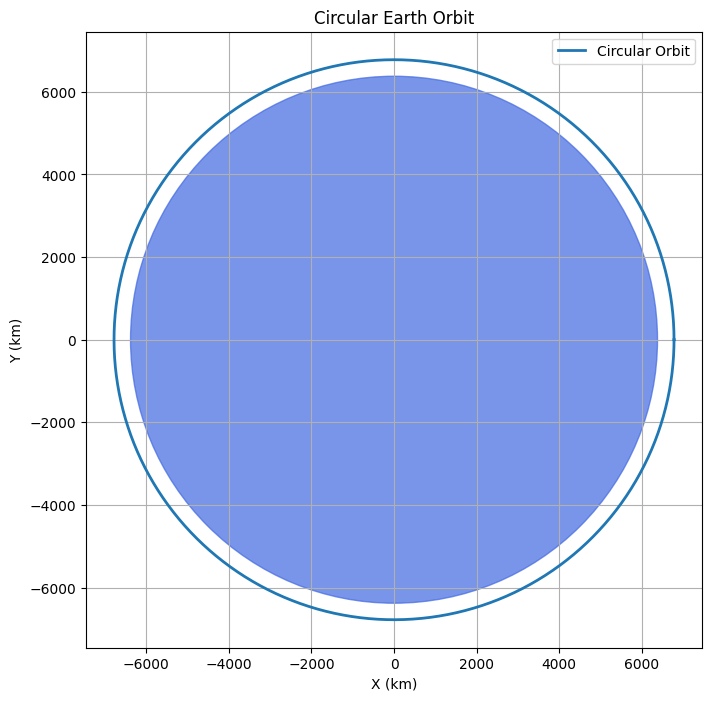

In [ ]:
# ============================================
# CIRCULAR ORBIT
# ============================================

theta = np.linspace(0, 2*np.pi, 1000)

orbit_radius = 6778.137

x = orbit_radius * np.cos(theta)
y = orbit_radius * np.sin(theta)

earth = plt.Circle(
    (0, 0),
    R_EARTH,
    color="royalblue",
    alpha=0.7
)

fig, ax = plt.subplots(figsize=(8, 8))

ax.add_patch(earth)

ax.plot(
    x,
    y,
    linewidth=2,
    label="Circular Orbit"
)

ax.set_aspect("equal")

ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")

ax.set_title("Circular Earth Orbit")

ax.grid(True)
ax.legend()

plt.show()

In [ ]:
# ============================================
# PERIGEE / APOGEE
# ============================================

# orbital_elements sözlüğünden değerleri alıyoruz
a = orbital_elements["semi_major_axis_a_km"]
e = orbital_elements["eccentricity_e"]

perigee_radius = a * (1 - e)
apogee_radius = a * (1 + e)

perigee_altitude = perigee_radius - R_EARTH
apogee_altitude = apogee_radius - R_EARTH

print(f"Perigee radius : {perigee_radius:.2f} km")
print(f"Apogee radius  : {apogee_radius:.2f} km")

print()

print(f"Perigee altitude: {perigee_altitude:.2f} km")
print(f"Apogee altitude : {apogee_altitude:.2f} km")

Perigee radius : 6771.36 km
Apogee radius  : 6784.92 km

Perigee altitude: 393.22 km
Apogee altitude : 406.78 km


In [ ]:
# ============================================
# VIS-VIVA EQUATION
# ============================================

def orbital_velocity(r, a):
    return np.sqrt(
        MU_EARTH * (
            2/r - 1/a
        )
    )


v_perigee = orbital_velocity(
    perigee_radius,
    a
)

v_apogee = orbital_velocity(
    apogee_radius,
    a
)

print(f"Velocity at perigee: {v_perigee:.4f} km/s")
print(f"Velocity at apogee : {v_apogee:.4f} km/s")

print()
print(f"Speed ratio: {v_perigee / v_apogee:.3f}")

Velocity at perigee: 7.6762 km/s
Velocity at apogee : 7.6609 km/s

Speed ratio: 1.002


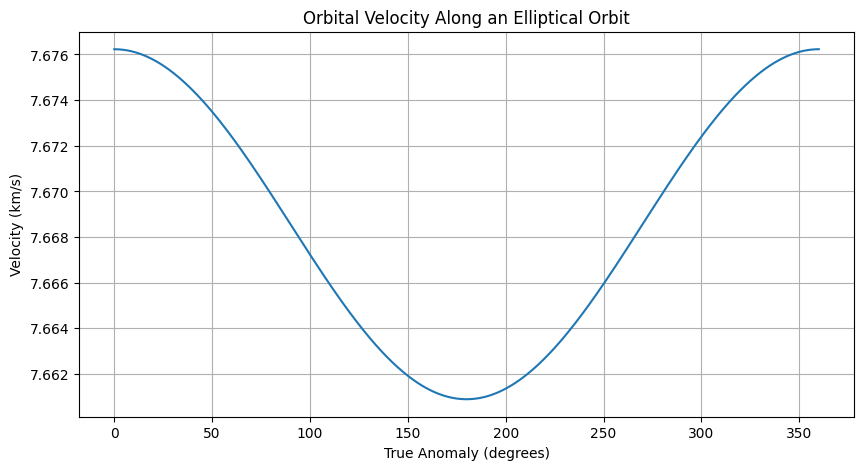

In [ ]:
# ============================================
# VELOCITY ALONG ELLIPTICAL ORBIT
# ============================================

# Gerçek anomali (nu) açısını 0 ile 2*pi arasında tanımlıyoruz (360 derece)
nu = np.linspace(0, 2 * np.pi, 500)

# Eliptik yörünge için r yarıçapını hesaplıyoruz: r = a * (1 - e^2) / (1 + e * cos(nu))
r = a * (1 - e**2) / (1 + e * np.cos(nu))

# Vis-viva denklemi ile her noktadaki hızı hesaplıyoruz
velocity_profile = orbital_velocity(r, a)

plt.figure(figsize=(10, 5))

plt.plot(
    np.degrees(nu),
    velocity_profile
)

plt.xlabel("True Anomaly (degrees)")
plt.ylabel("Velocity (km/s)")

plt.title(
    "Orbital Velocity Along an Elliptical Orbit"
)

plt.grid(True)

plt.show()

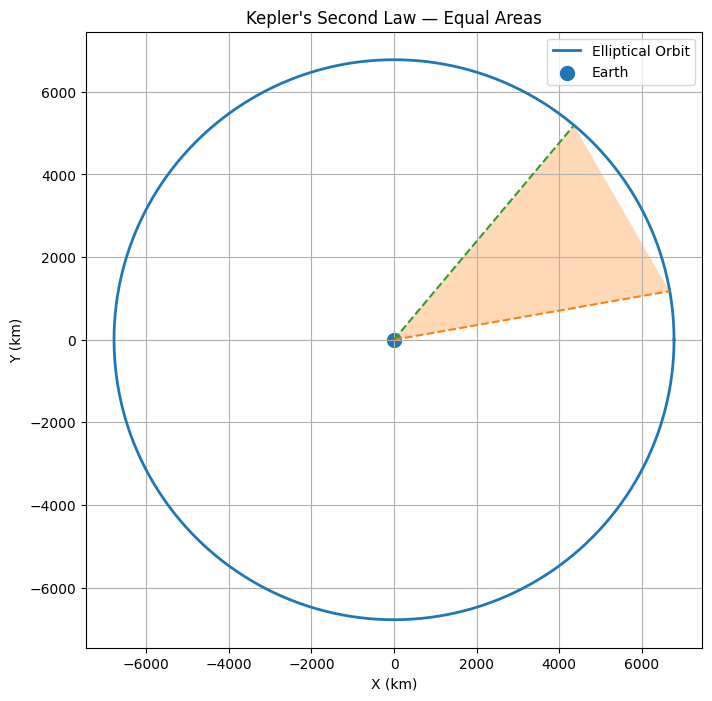

In [ ]:
# ============================================
# KEPLER'S SECOND LAW
# EQUAL AREAS
# ============================================

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(
    x,
    y,
    linewidth=2,
    label="Elliptical Orbit"
)

ax.scatter(
    0,
    0,
    s=100,
    label="Earth"
)

# Two positions close to perigee
theta1 = np.radians(10)
theta2 = np.radians(50)

r1 = (a * (1 - e**2)) / (1 + e*np.cos(theta1))
r2 = (a * (1 - e**2)) / (1 + e*np.cos(theta2))

p1 = np.array([
    r1*np.cos(theta1),
    r1*np.sin(theta1)
])

p2 = np.array([
    r2*np.cos(theta2),
    r2*np.sin(theta2)
])

ax.fill(
    [0, p1[0], p2[0]],
    [0, p1[1], p2[1]],
    alpha=0.3
)

ax.plot(
    [0, p1[0]],
    [0, p1[1]],
    "--"
)

ax.plot(
    [0, p2[0]],
    [0, p2[1]],
    "--"
)

ax.set_aspect("equal")

ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")

ax.set_title(
    "Kepler's Second Law — Equal Areas"
)

ax.grid(True)
ax.legend()

plt.show()

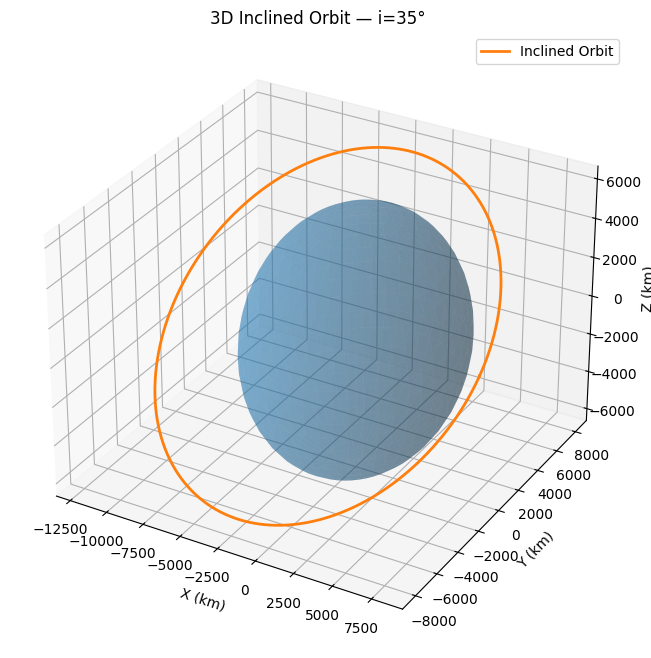

In [ ]:
# ============================================
# 3D INCLINED ORBIT
# ============================================

a = 10000
e = 0.2

inclination_deg = 35
inclination = np.radians(inclination_deg)

nu = np.linspace(0, 2*np.pi, 1000)

r = (
    a * (1 - e**2)
    /
    (1 + e*np.cos(nu))
)

# Orbital-plane coordinates
x_orbit = r * np.cos(nu)
y_orbit = r * np.sin(nu)
z_orbit = np.zeros_like(nu)

# Rotate orbit around X-axis
x_3d = x_orbit

y_3d = (
    y_orbit * np.cos(inclination)
    -
    z_orbit * np.sin(inclination)
)

z_3d = (
    y_orbit * np.sin(inclination)
    +
    z_orbit * np.cos(inclination)
)

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

# Earth
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 25)

xs = R_EARTH * np.outer(
    np.cos(u),
    np.sin(v)
)

ys = R_EARTH * np.outer(
    np.sin(u),
    np.sin(v)
)

zs = R_EARTH * np.outer(
    np.ones(np.size(u)),
    np.cos(v)
)

ax.plot_surface(
    xs,
    ys,
    zs,
    alpha=0.35
)

# Orbit
ax.plot(
    x_3d,
    y_3d,
    z_3d,
    linewidth=2,
    label="Inclined Orbit"
)

ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")

ax.set_title(
    f"3D Inclined Orbit — i={inclination_deg}°"
)

ax.legend()

plt.show()

In [ ]:
# ============================================
# 🛰️ MISSION CONTROL — ORBIT CALCULATOR
# ============================================

def mission_control_orbit(altitude_km):

    r = R_EARTH + altitude_km

    gravity = MU_EARTH / r**2

    circular_velocity = np.sqrt(
        MU_EARTH / r
    )

    escape_velocity = np.sqrt(
        2 * MU_EARTH / r
    )

    period = (
        2 * np.pi *
        np.sqrt(r**3 / MU_EARTH)
    )

    print("=" * 50)
    print("       🛰️ MISSION CONTROL")
    print("        ORBIT ANALYSIS")
    print("=" * 50)

    print(f"Altitude              : {altitude_km:.2f} km")
    print(f"Orbital radius        : {r:.2f} km")

    print("-" * 50)

    print(
        f"Gravity               : "
        f"{gravity*20000:.4f} m/s²"
    )

    print(
        f"Circular velocity     : "
        f"{circular_velocity:.4f} km/s"
    )

    print(
        f"Escape velocity       : "
        f"{escape_velocity:.4f} km/s"
    )

    print(
        f"Orbital period        : "
        f"{period/60:.2f} min"
    )

    print(
        f"Orbital period        : "
        f"{period/3600:.2f} h"
    )

    print("=" * 50)


mission_control_orbit(200)

       🛰️ MISSION CONTROL
        ORBIT ANALYSIS
Altitude              : 200.00 km
Orbital radius        : 6578.14 km
--------------------------------------------------
Gravity               : 184.2307 m/s²
Circular velocity     : 7.7843 km/s
Escape velocity       : 11.0086 km/s
Orbital period        : 88.49 min
Orbital period        : 1.47 h


In [40]:
!npm install three
!npm install -D @types/three

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹
added 1 package in 1s
⠹⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 7 packages, and audited 9 packages in 2s
⠸
found 0 vulnerabilities
⠼

In [42]:
!npm run dev

npm error Missing script: "dev"
npm error
npm error To see a list of scripts, run:
npm error   npm run
npm error A complete log of this run can be found in: /root/.npm/_logs/2026-10-08T13_49_51_813Z-debug-0.log


In [ ]:
import * as THREE from "three";
import { OrbitControls } from "three/examples/jsm/controls/OrbitControls.js";

// ============================================================
// SCENE
// ============================================================

const scene = new THREE.Scene();

scene.background = new THREE.Color(0x000000);

// ============================================================
// CAMERA
// ============================================================

const camera = new THREE.PerspectiveCamera(
    45,
    window.innerWidth / window.innerHeight,
    0.01,
    1000
);

camera.position.set(7, 5, 8);

// ============================================================
// RENDERER
// ============================================================

const renderer = new THREE.WebGLRenderer({
    antialias: true,
    powerPreference: "high-performance"
});

renderer.setSize(window.innerWidth, window.innerHeight);
renderer.setPixelRatio(Math.min(window.devicePixelRatio, 2));

renderer.outputColorSpace = THREE.SRGBColorSpace;

renderer.toneMapping = THREE.ACESFilmicToneMapping;
renderer.toneMappingExposure = 1.15;

document.body.appendChild(renderer.domElement);

// ============================================================
// CAMERA CONTROLS
// ============================================================

const controls = new OrbitControls(camera, renderer.domElement);

controls.enableDamping = true;
controls.dampingFactor = 0.05;

controls.minDistance = 2.2;
controls.maxDistance = 30;

controls.target.set(0, 0, 0);

// ============================================================
// LIGHTING
// ============================================================

const ambientLight = new THREE.AmbientLight(
    0xffffff,
    0.25
);

scene.add(ambientLight);


const sunLight = new THREE.DirectionalLight(
    0xffffff,
    3.2
);

sunLight.position.set(
    8,
    5,
    6
);

scene.add(sunLight);


// ============================================================
// STAR FIELD
// ============================================================

const starGeometry = new THREE.BufferGeometry();

const starCount = 7000;

const starPositions = new Float32Array(
    starCount * 3
);

for (let i = 0; i < starCount; i++) {

    const radius = 40 + Math.random() * 100;

    const theta =
        Math.random() * Math.PI * 2;

    const phi =
        Math.acos(
            2 * Math.random() - 1
        );

    const x =
        radius *
        Math.sin(phi) *
        Math.cos(theta);

    const y =
        radius *
        Math.sin(phi) *
        Math.sin(theta);

    const z =
        radius *
        Math.cos(phi);

    starPositions[i * 3] = x;
    starPositions[i * 3 + 1] = y;
    starPositions[i * 3 + 2] = z;
}

starGeometry.setAttribute(
    "position",
    new THREE.BufferAttribute(
        starPositions,
        3
    )
);

const starMaterial =
    new THREE.PointsMaterial({

        color: 0xffffff,

        size: 0.035,

        sizeAttenuation: true,

        transparent: true,

        opacity: 0.9
    });

const stars =
    new THREE.Points(
        starGeometry,
        starMaterial
    );

scene.add(stars);

// ============================================================
// EARTH
// ============================================================

const earthRadius = 1;

const earthGeometry =
    new THREE.SphereGeometry(
        earthRadius,
        128,
        128
    );

const textureLoader =
    new THREE.TextureLoader();

const earthTexture =
    textureLoader.load(
        "https://svs.gsfc.nasa.gov/vis/a000000/a003600/a003615/flat_earth_Largest_still.0330.jpg"
    );

earthTexture.colorSpace =
    THREE.SRGBColorSpace;

const earthMaterial =
    new THREE.MeshPhongMaterial({

        map: earthTexture,

        shininess: 12,

        specular:
            new THREE.Color(0x333333)
    });

const earth =
    new THREE.Mesh(
        earthGeometry,
        earthMaterial
    );

scene.add(earth);

// ============================================================
// ATMOSPHERE
// ============================================================

const atmosphereGeometry =
    new THREE.SphereGeometry(
        1.035,
        96,
        96
    );

const atmosphereMaterial =
    new THREE.MeshBasicMaterial({

        color: 0x4da6ff,

        transparent: true,

        opacity: 0.12,

        side: THREE.BackSide,

        blending:
            THREE.AdditiveBlending,

        depthWrite: false
    });

const atmosphere =
    new THREE.Mesh(
        atmosphereGeometry,
        atmosphereMaterial
    );

scene.add(atmosphere);

// ============================================================
// ORBIT GROUP
// ============================================================

const orbitGroup =
    new THREE.Group();

scene.add(orbitGroup);

// Inclination
const inclinationDeg = 35;

const inclination =
    THREE.MathUtils.degToRad(
        inclinationDeg
    );

orbitGroup.rotation.x =
    inclination;

// ============================================================
// ORBIT MATERIALS
// ============================================================

const circularMaterial =
    new THREE.LineBasicMaterial({

        color: 0x00aaff,

        transparent: true,

        opacity: 0.7
    });


const ellipticalMaterial =
    new THREE.LineBasicMaterial({

        color: 0xaa55ff,

        transparent: true,

        opacity: 0.85
    });


const parabolicMaterial =
    new THREE.LineBasicMaterial({

        color: 0xff8844,

        transparent: true,

        opacity: 0.8
    });

// ============================================================
// CIRCULAR ORBIT
// ============================================================

const circularRadius = 2.0;

const circularPoints: THREE.Vector3[] = [];

for (
    let i = 0;
    i <= 512;
    i++
) {

    const theta =
        (i / 512) *
        Math.PI *
        2;

    circularPoints.push(
        new THREE.Vector3(
            circularRadius *
                Math.cos(theta),

            circularRadius *
                Math.sin(theta),

            0
        )
    );
}

const circularGeometry =
    new THREE.BufferGeometry()
        .setFromPoints(
            circularPoints
        );

const circularOrbit =
    new THREE.Line(
        circularGeometry,
        circularMaterial
    );

orbitGroup.add(
    circularOrbit
);

// ============================================================
// ELLIPTICAL ORBIT
// ============================================================

const ellipseA = 3.0;
const ellipseE = 0.35;

const ellipticalPoints:
    THREE.Vector3[] = [];

for (
    let i = 0;
    i <= 512;
    i++
) {

    const nu =
        (i / 512) *
        Math.PI *
        2;

    const r =
        (
            ellipseA *
            (1 - ellipseE * ellipseE)
        ) /
        (
            1 +
            ellipseE *
            Math.cos(nu)
        );

    const x =
        r * Math.cos(nu);

    const y =
        r * Math.sin(nu);

    ellipticalPoints.push(
        new THREE.Vector3(
            x,
            y,
            0
        )
    );
}

const ellipticalGeometry =
    new THREE.BufferGeometry()
        .setFromPoints(
            ellipticalPoints
        );

const ellipticalOrbit =
    new THREE.Line(
        ellipticalGeometry,
        ellipticalMaterial
    );

orbitGroup.add(
    ellipticalOrbit
);

// ============================================================
// PARABOLIC TRAJECTORY
// ============================================================
//
// r = p / (1 + cos(theta))
//
// A parabola represents a limiting escape trajectory.
// It does NOT form a closed orbit.
//

const parabolaP = 3.5;

const parabolicPoints:
    THREE.Vector3[] = [];

const minAngle =
    THREE.MathUtils.degToRad(-120);

const maxAngle =
    THREE.MathUtils.degToRad(120);

for (
    let i = 0;
    i <= 512;
    i++
) {

    const nu =
        minAngle +
        (
            (maxAngle - minAngle) *
            i /
            512
        );

    const denominator =
        1 + Math.cos(nu);

    const r =
        parabolaP /
        denominator;

    const x =
        r * Math.cos(nu);

    const y =
        r * Math.sin(nu);

    parabolicPoints.push(
        new THREE.Vector3(
            x,
            y,
            0
        )
    );
}

const parabolicGeometry =
    new THREE.BufferGeometry()
        .setFromPoints(
            parabolicPoints
        );

const parabolicOrbit =
    new THREE.Line(
        parabolicGeometry,
        parabolicMaterial
    );

orbitGroup.add(
    parabolicOrbit
);

// ============================================================
// ORBITAL PLANE
// ============================================================

const planeGeometry =
    new THREE.CircleGeometry(
        4.5,
        96
    );

const planeMaterial =
    new THREE.MeshBasicMaterial({

        color: 0x3366ff,

        transparent: true,

        opacity: 0.025,

        side: THREE.DoubleSide,

        depthWrite: false
    });

const orbitalPlane =
    new THREE.Mesh(
        planeGeometry,
        planeMaterial
    );

orbitGroup.add(
    orbitalPlane
);

// ============================================================
// SATELLITE
// ============================================================

const satellite =
    new THREE.Group();

orbitGroup.add(
    satellite
);

// Main body

const satelliteBodyGeometry =
    new THREE.BoxGeometry(
        0.14,
        0.22,
        0.14
    );

const satelliteBodyMaterial =
    new THREE.MeshStandardMaterial({

        color: 0x777777,

        metalness: 0.8,

        roughness: 0.3
    });

const satelliteBody =
    new THREE.Mesh(
        satelliteBodyGeometry,
        satelliteBodyMaterial
    );

satellite.add(
    satelliteBody
);

// ============================================================
// SOLAR PANELS
// ============================================================

const panelGeometry =
    new THREE.BoxGeometry(
        0.55,
        0.025,
        0.22
    );

const panelMaterial =
    new THREE.MeshStandardMaterial({

        color: 0x173b68,

        metalness: 0.5,

        roughness: 0.35
    });

const panelLeft =
    new THREE.Mesh(
        panelGeometry,
        panelMaterial
    );

panelLeft.position.x =
    -0.34;

satellite.add(
    panelLeft
);


const panelRight =
    new THREE.Mesh(
        panelGeometry,
        panelMaterial
    );

panelRight.position.x =
    0.34;

satellite.add(
    panelRight
);

// ============================================================
// SATELLITE GLOW
// ============================================================

const glowGeometry =
    new THREE.SphereGeometry(
        0.13,
        24,
        24
    );

const glowMaterial =
    new THREE.MeshBasicMaterial({

        color: 0xffff66,

        transparent: true,

        opacity: 0.55,

        blending:
            THREE.AdditiveBlending
    });

const satelliteGlow =
    new THREE.Mesh(
        glowGeometry,
        glowMaterial
    );

satellite.add(
    satelliteGlow
);

// ============================================================
// SATELLITE TRAIL
// ============================================================

const trailMaterial =
    new THREE.LineBasicMaterial({

        color: 0xffff66,

        transparent: true,

        opacity: 0.35
    });

const trailPoints:
    THREE.Vector3[] = [];

const trailGeometry =
    new THREE.BufferGeometry();

const trail =
    new THREE.Line(
        trailGeometry,
        trailMaterial
    );

orbitGroup.add(
    trail
);

// ============================================================
// KEPLER EQUATION
// ============================================================
//
// M = E - e sin(E)
//
// We solve E numerically using Newton-Raphson.
//

function solveKeplerEquation(
    M: number,
    e: number
): number {

    let E = M;

    for (let i = 0; i < 10; i++) {

        const f =
            E -
            e * Math.sin(E) -
            M;

        const derivative =
            1 -
            e * Math.cos(E);

        E =
            E -
            f /
            derivative;
    }

    return E;
}

// ============================================================
// ELLIPTICAL ORBIT POSITION
// ============================================================

function getEllipticalPosition(
    time: number
): THREE.Vector3 {

    const e = ellipseE;
    const a = ellipseA;

    // Mean motion
    const n = 0.55;

    // Mean anomaly
    const M =
        (n * time) %
        (Math.PI * 2);

    // Solve Kepler equation
    const E =
        solveKeplerEquation(
            M,
            e
        );

    // Position in orbital plane
    const x =
        a *
        (Math.cos(E) - e);

    const y =
        a *
        Math.sqrt(1 - e * e) *
        Math.sin(E);

    return new THREE.Vector3(
        x,
        y,
        0
    );
}

// ============================================================
// POSITION VECTOR
// ============================================================

const positionVectorMaterial =
    new THREE.LineBasicMaterial({

        color: 0xffff00,

        transparent: true,

        opacity: 0.45
    });

const positionVectorGeometry =
    new THREE.BufferGeometry()
        .setFromPoints([

            new THREE.Vector3(0, 0, 0),

            new THREE.Vector3(0, 0, 0)
        ]);

const positionVector =
    new THREE.Line(
        positionVectorGeometry,
        positionVectorMaterial
    );

orbitGroup.add(
    positionVector
);

// ============================================================
// ORIGIN MARKER
// ============================================================

const originGeometry =
    new THREE.SphereGeometry(
        0.025,
        16,
        16
    );

const originMaterial =
    new THREE.MeshBasicMaterial({

        color: 0xffffff
    });

const originMarker =
    new THREE.Mesh(
        originGeometry,
        originMaterial
    );

orbitGroup.add(
    originMarker
);

// ============================================================
// ANIMATION
// ============================================================

const clock =
    new THREE.Clock();

let elapsedTime = 0;

function animate() {

    requestAnimationFrame(
        animate
    );

    const delta =
        clock.getDelta();

    elapsedTime += delta;

    // --------------------------------------------------------
    // EARTH ROTATION
    // --------------------------------------------------------

    earth.rotation.y +=
        delta * 0.05;

    atmosphere.rotation.y =
        earth.rotation.y;

    // --------------------------------------------------------
    // STAR ROTATION
    // --------------------------------------------------------

    stars.rotation.y +=
        delta * 0.001;

    // --------------------------------------------------------
    // SATELLITE ORBIT
    // --------------------------------------------------------

    const position =
        getEllipticalPosition(
            elapsedTime
        );

    satellite.position.copy(
        position
    );

    // --------------------------------------------------------
    // SATELLITE SELF ROTATION
    // --------------------------------------------------------

    satellite.rotation.y +=
        delta * 2.5;

    satellite.rotation.z +=
        delta * 0.8;

    // --------------------------------------------------------
    // POSITION VECTOR
    // --------------------------------------------------------

    const vectorPositions =
        new Float32Array([

            0, 0, 0,

            position.x,
            position.y,
            position.z
        ]);

    positionVectorGeometry.setAttribute(
        "position",
        new THREE.BufferAttribute(
            vectorPositions,
            3
        )
    );

    // --------------------------------------------------------
    // SATELLITE TRAIL
    // --------------------------------------------------------

    trailPoints.push(
        position.clone()
    );

    if (
        trailPoints.length > 120
    ) {

        trailPoints.shift();
    }

    trail.geometry.dispose();

    trail.geometry =
        new THREE.BufferGeometry()
            .setFromPoints(
                trailPoints
            );

    // --------------------------------------------------------
    // CAMERA
    // --------------------------------------------------------

    controls.update();

    // --------------------------------------------------------
    // RENDER
    // --------------------------------------------------------

    renderer.render(
        scene,
        camera
    );
}

animate();

// ============================================================
// RESIZE
// ============================================================

window.addEventListener(
    "resize",
    () => {

        camera.aspect =
            window.innerWidth /
            window.innerHeight;

        camera.updateProjectionMatrix();

        renderer.setSize(
            window.innerWidth,
            window.innerHeight
        );

        renderer.setPixelRatio(
            Math.min(
                window.devicePixelRatio,
                2
            )
        );
    }
);
import * as THREE from "three";
import { OrbitControls } from "three/examples/jsm/controls/OrbitControls.js";

// ============================================================
// SCENE
// ============================================================

const scene = new THREE.Scene();

scene.background = new THREE.Color(0x000000);

// ============================================================
// CAMERA
// ============================================================

const camera = new THREE.PerspectiveCamera(
    45,
    window.innerWidth / window.innerHeight,
    0.01,
    1000
);

camera.position.set(7, 5, 8);

// ============================================================
// RENDERER
// ============================================================

const renderer = new THREE.WebGLRenderer({
    antialias: true,
    powerPreference: "high-performance"
});

renderer.setSize(window.innerWidth, window.innerHeight);
renderer.setPixelRatio(Math.min(window.devicePixelRatio, 2));

renderer.outputColorSpace = THREE.SRGBColorSpace;

renderer.toneMapping = THREE.ACESFilmicToneMapping;
renderer.toneMappingExposure = 1.15;

document.body.appendChild(renderer.domElement);

// ============================================================
// CAMERA CONTROLS
// ============================================================

const controls = new OrbitControls(camera, renderer.domElement);

controls.enableDamping = true;
controls.dampingFactor = 0.05;

controls.minDistance = 2.2;
controls.maxDistance = 30;

controls.target.set(0, 0, 0);

// ============================================================
// LIGHTING
// ============================================================

const ambientLight = new THREE.AmbientLight(
    0xffffff,
    0.25
);

scene.add(ambientLight);


const sunLight = new THREE.DirectionalLight(
    0xffffff,
    3.2
);

sunLight.position.set(
    8,
    5,
    6
);

scene.add(sunLight);


// ============================================================
// STAR FIELD
// ============================================================

const starGeometry = new THREE.BufferGeometry();

const starCount = 7000;

const starPositions = new Float32Array(
    starCount * 3
);

for (let i = 0; i < starCount; i++) {

    const radius = 40 + Math.random() * 100;

    const theta =
        Math.random() * Math.PI * 2;

    const phi =
        Math.acos(
            2 * Math.random() - 1
        );

    const x =
        radius *
        Math.sin(phi) *
        Math.cos(theta);

    const y =
        radius *
        Math.sin(phi) *
        Math.sin(theta);

    const z =
        radius *
        Math.cos(phi);

    starPositions[i * 3] = x;
    starPositions[i * 3 + 1] = y;
    starPositions[i * 3 + 2] = z;
}

starGeometry.setAttribute(
    "position",
    new THREE.BufferAttribute(
        starPositions,
        3
    )
);

const starMaterial =
    new THREE.PointsMaterial({

        color: 0xffffff,

        size: 0.035,

        sizeAttenuation: true,

        transparent: true,

        opacity: 0.9
    });

const stars =
    new THREE.Points(
        starGeometry,
        starMaterial
    );

scene.add(stars);

// ============================================================
// EARTH
// ============================================================

const earthRadius = 1;

const earthGeometry =
    new THREE.SphereGeometry(
        earthRadius,
        128,
        128
    );

const textureLoader =
    new THREE.TextureLoader();

const earthTexture =
    textureLoader.load(
        "https://svs.gsfc.nasa.gov/vis/a000000/a003600/a003615/flat_earth_Largest_still.0330.jpg"
    );

earthTexture.colorSpace =
    THREE.SRGBColorSpace;

const earthMaterial =
    new THREE.MeshPhongMaterial({

        map: earthTexture,

        shininess: 12,

        specular:
            new THREE.Color(0x333333)
    });

const earth =
    new THREE.Mesh(
        earthGeometry,
        earthMaterial
    );

scene.add(earth);

// ============================================================
// ATMOSPHERE
// ============================================================

const atmosphereGeometry =
    new THREE.SphereGeometry(
        1.035,
        96,
        96
    );

const atmosphereMaterial =
    new THREE.MeshBasicMaterial({

        color: 0x4da6ff,

        transparent: true,

        opacity: 0.12,

        side: THREE.BackSide,

        blending:
            THREE.AdditiveBlending,

        depthWrite: false
    });

const atmosphere =
    new THREE.Mesh(
        atmosphereGeometry,
        atmosphereMaterial
    );

scene.add(atmosphere);

// ============================================================
// ORBIT GROUP
// ============================================================

const orbitGroup =
    new THREE.Group();

scene.add(orbitGroup);

// Inclination
const inclinationDeg = 35;

const inclination =
    THREE.MathUtils.degToRad(
        inclinationDeg
    );

orbitGroup.rotation.x =
    inclination;

// ============================================================
// ORBIT MATERIALS
// ============================================================

const circularMaterial =
    new THREE.LineBasicMaterial({

        color: 0x00aaff,

        transparent: true,

        opacity: 0.7
    });


const ellipticalMaterial =
    new THREE.LineBasicMaterial({

        color: 0xaa55ff,

        transparent: true,

        opacity: 0.85
    });


const parabolicMaterial =
    new THREE.LineBasicMaterial({

        color: 0xff8844,

        transparent: true,

        opacity: 0.8
    });

// ============================================================
// CIRCULAR ORBIT
// ============================================================

const circularRadius = 2.0;

const circularPoints: THREE.Vector3[] = [];

for (
    let i = 0;
    i <= 512;
    i++
) {

    const theta =
        (i / 512) *
        Math.PI *
        2;

    circularPoints.push(
        new THREE.Vector3(
            circularRadius *
                Math.cos(theta),

            circularRadius *
                Math.sin(theta),

            0
        )
    );
}

const circularGeometry =
    new THREE.BufferGeometry()
        .setFromPoints(
            circularPoints
        );

const circularOrbit =
    new THREE.Line(
        circularGeometry,
        circularMaterial
    );

orbitGroup.add(
    circularOrbit
);

// ============================================================
// ELLIPTICAL ORBIT
// ============================================================

const ellipseA = 3.0;
const ellipseE = 0.35;

const ellipticalPoints:
    THREE.Vector3[] = [];

for (
    let i = 0;
    i <= 512;
    i++
) {

    const nu =
        (i / 512) *
        Math.PI *
        2;

    const r =
        (
            ellipseA *
            (1 - ellipseE * ellipseE)
        ) /
        (
            1 +
            ellipseE *
            Math.cos(nu)
        );

    const x =
        r * Math.cos(nu);

    const y =
        r * Math.sin(nu);

    ellipticalPoints.push(
        new THREE.Vector3(
            x,
            y,
            0
        )
    );
}

const ellipticalGeometry =
    new THREE.BufferGeometry()
        .setFromPoints(
            ellipticalPoints
        );

const ellipticalOrbit =
    new THREE.Line(
        ellipticalGeometry,
        ellipticalMaterial
    );

orbitGroup.add(
    ellipticalOrbit
);

// ============================================================
// PARABOLIC TRAJECTORY
// ============================================================
//
// r = p / (1 + cos(theta))
//
// A parabola represents a limiting escape trajectory.
// It does NOT form a closed orbit.
//

const parabolaP = 3.5;

const parabolicPoints:
    THREE.Vector3[] = [];

const minAngle =
    THREE.MathUtils.degToRad(-120);

const maxAngle =
    THREE.MathUtils.degToRad(120);

for (
    let i = 0;
    i <= 512;
    i++
) {

    const nu =
        minAngle +
        (
            (maxAngle - minAngle) *
            i /
            512
        );

    const denominator =
        1 + Math.cos(nu);

    const r =
        parabolaP /
        denominator;

    const x =
        r * Math.cos(nu);

    const y =
        r * Math.sin(nu);

    parabolicPoints.push(
        new THREE.Vector3(
            x,
            y,
            0
        )
    );
}

const parabolicGeometry =
    new THREE.BufferGeometry()
        .setFromPoints(
            parabolicPoints
        );

const parabolicOrbit =
    new THREE.Line(
        parabolicGeometry,
        parabolicMaterial
    );

orbitGroup.add(
    parabolicOrbit
);

// ============================================================
// ORBITAL PLANE
// ============================================================

const planeGeometry =
    new THREE.CircleGeometry(
        4.5,
        96
    );

const planeMaterial =
    new THREE.MeshBasicMaterial({

        color: 0x3366ff,

        transparent: true,

        opacity: 0.025,

        side: THREE.DoubleSide,

        depthWrite: false
    });

const orbitalPlane =
    new THREE.Mesh(
        planeGeometry,
        planeMaterial
    );

orbitGroup.add(
    orbitalPlane
);

// ============================================================
// SATELLITE
// ============================================================

const satellite =
    new THREE.Group();

orbitGroup.add(
    satellite
);

// Main body

const satelliteBodyGeometry =
    new THREE.BoxGeometry(
        0.14,
        0.22,
        0.14
    );

const satelliteBodyMaterial =
    new THREE.MeshStandardMaterial({

        color: 0x777777,

        metalness: 0.8,

        roughness: 0.3
    });

const satelliteBody =
    new THREE.Mesh(
        satelliteBodyGeometry,
        satelliteBodyMaterial
    );

satellite.add(
    satelliteBody
);

// ============================================================
// SOLAR PANELS
// ============================================================

const panelGeometry =
    new THREE.BoxGeometry(
        0.55,
        0.025,
        0.22
    );

const panelMaterial =
    new THREE.MeshStandardMaterial({

        color: 0x173b68,

        metalness: 0.5,

        roughness: 0.35
    });

const panelLeft =
    new THREE.Mesh(
        panelGeometry,
        panelMaterial
    );

panelLeft.position.x =
    -0.34;

satellite.add(
    panelLeft
);


const panelRight =
    new THREE.Mesh(
        panelGeometry,
        panelMaterial
    );

panelRight.position.x =
    0.34;

satellite.add(
    panelRight
);

// ============================================================
// SATELLITE GLOW
// ============================================================

const glowGeometry =
    new THREE.SphereGeometry(
        0.13,
        24,
        24
    );

const glowMaterial =
    new THREE.MeshBasicMaterial({

        color: 0xffff66,

        transparent: true,

        opacity: 0.55,

        blending:
            THREE.AdditiveBlending
    });

const satelliteGlow =
    new THREE.Mesh(
        glowGeometry,
        glowMaterial
    );

satellite.add(
    satelliteGlow
);

// ============================================================
// SATELLITE TRAIL
// ============================================================

const trailMaterial =
    new THREE.LineBasicMaterial({

        color: 0xffff66,

        transparent: true,

        opacity: 0.35
    });

const trailPoints:
    THREE.Vector3[] = [];

const trailGeometry =
    new THREE.BufferGeometry();

const trail =
    new THREE.Line(
        trailGeometry,
        trailMaterial
    );

orbitGroup.add(
    trail
);

// ============================================================
// KEPLER EQUATION
// ============================================================
//
// M = E - e sin(E)
//
// We solve E numerically using Newton-Raphson.
//

function solveKeplerEquation(
    M: number,
    e: number
): number {

    let E = M;

    for (let i = 0; i < 10; i++) {

        const f =
            E -
            e * Math.sin(E) -
            M;

        const derivative =
            1 -
            e * Math.cos(E);

        E =
            E -
            f /
            derivative;
    }

    return E;
}

// ============================================================
// ELLIPTICAL ORBIT POSITION
// ============================================================

function getEllipticalPosition(
    time: number
): THREE.Vector3 {

    const e = ellipseE;
    const a = ellipseA;

    // Mean motion
    const n = 0.55;

    // Mean anomaly
    const M =
        (n * time) %
        (Math.PI * 2);

    // Solve Kepler equation
    const E =
        solveKeplerEquation(
            M,
            e
        );

    // Position in orbital plane
    const x =
        a *
        (Math.cos(E) - e);

    const y =
        a *
        Math.sqrt(1 - e * e) *
        Math.sin(E);

    return new THREE.Vector3(
        x,
        y,
        0
    );
}

// ============================================================
// POSITION VECTOR
// ============================================================

const positionVectorMaterial =
    new THREE.LineBasicMaterial({

        color: 0xffff00,

        transparent: true,

        opacity: 0.45
    });

const positionVectorGeometry =
    new THREE.BufferGeometry()
        .setFromPoints([

            new THREE.Vector3(0, 0, 0),

            new THREE.Vector3(0, 0, 0)
        ]);

const positionVector =
    new THREE.Line(
        positionVectorGeometry,
        positionVectorMaterial
    );

orbitGroup.add(
    positionVector
);

// ============================================================
// ORIGIN MARKER
// ============================================================

const originGeometry =
    new THREE.SphereGeometry(
        0.025,
        16,
        16
    );

const originMaterial =
    new THREE.MeshBasicMaterial({

        color: 0xffffff
    });

const originMarker =
    new THREE.Mesh(
        originGeometry,
        originMaterial
    );

orbitGroup.add(
    originMarker
);

// ============================================================
// ANIMATION
// ============================================================

const clock =
    new THREE.Clock();

let elapsedTime = 0;

function animate() {

    requestAnimationFrame(
        animate
    );

    const delta =
        clock.getDelta();

    elapsedTime += delta;

    // --------------------------------------------------------
    // EARTH ROTATION
    // --------------------------------------------------------

    earth.rotation.y +=
        delta * 0.05;

    atmosphere.rotation.y =
        earth.rotation.y;

    // --------------------------------------------------------
    // STAR ROTATION
    // --------------------------------------------------------

    stars.rotation.y +=
        delta * 0.001;

    // --------------------------------------------------------
    // SATELLITE ORBIT
    // --------------------------------------------------------

    const position =
        getEllipticalPosition(
            elapsedTime
        );

    satellite.position.copy(
        position
    );

    // --------------------------------------------------------
    // SATELLITE SELF ROTATION
    // --------------------------------------------------------

    satellite.rotation.y +=
        delta * 2.5;

    satellite.rotation.z +=
        delta * 0.8;

    // --------------------------------------------------------
    // POSITION VECTOR
    // --------------------------------------------------------

    const vectorPositions =
        new Float32Array([

            0, 0, 0,

            position.x,
            position.y,
            position.z
        ]);

    positionVectorGeometry.setAttribute(
        "position",
        new THREE.BufferAttribute(
            vectorPositions,
            3
        )
    );

    // --------------------------------------------------------
    // SATELLITE TRAIL
    // --------------------------------------------------------

    trailPoints.push(
        position.clone()
    );

    if (
        trailPoints.length > 120
    ) {

        trailPoints.shift();
    }

    trail.geometry.dispose();

    trail.geometry =
        new THREE.BufferGeometry()
            .setFromPoints(
                trailPoints
            );

    // --------------------------------------------------------
    // CAMERA
    // --------------------------------------------------------

    controls.update();

    // --------------------------------------------------------
    // RENDER
    // --------------------------------------------------------

    renderer.render(
        scene,
        camera
    );
}

animate();

// ============================================================
// RESIZE
// ============================================================

window.addEventListener(
    "resize",
    () => {

        camera.aspect =
            window.innerWidth /
            window.innerHeight;

        camera.updateProjectionMatrix();

        renderer.setSize(
            window.innerWidth,
            window.innerHeight
        );

        renderer.setPixelRatio(
            Math.min(
                window.devicePixelRatio,
                2
            )
        );
    }
);
import * as THREE from "three";
import { OrbitControls } from "three/examples/jsm/controls/OrbitControls.js";

// ============================================================
// SCENE
// ============================================================

const scene = new THREE.Scene();

scene.background = new THREE.Color(0x000000);

// ============================================================
// CAMERA
// ============================================================

const camera = new THREE.PerspectiveCamera(
    45,
    window.innerWidth / window.innerHeight,
    0.01,
    1000
);

camera.position.set(7, 5, 8);

// ============================================================
// RENDERER
// ============================================================

const renderer = new THREE.WebGLRenderer({
    antialias: true,
    powerPreference: "high-performance"
});

renderer.setSize(window.innerWidth, window.innerHeight);
renderer.setPixelRatio(Math.min(window.devicePixelRatio, 2));

renderer.outputColorSpace = THREE.SRGBColorSpace;

renderer.toneMapping = THREE.ACESFilmicToneMapping;
renderer.toneMappingExposure = 1.15;

document.body.appendChild(renderer.domElement);

// ============================================================
// CAMERA CONTROLS
// ============================================================

const controls = new OrbitControls(camera, renderer.domElement);

controls.enableDamping = true;
controls.dampingFactor = 0.05;

controls.minDistance = 2.2;
controls.maxDistance = 30;

controls.target.set(0, 0, 0);

// ============================================================
// LIGHTING
// ============================================================

const ambientLight = new THREE.AmbientLight(
    0xffffff,
    0.25
);

scene.add(ambientLight);


const sunLight = new THREE.DirectionalLight(
    0xffffff,
    3.2
);

sunLight.position.set(
    8,
    5,
    6
);

scene.add(sunLight);


// ============================================================
// STAR FIELD
// ============================================================

const starGeometry = new THREE.BufferGeometry();

const starCount = 7000;

const starPositions = new Float32Array(
    starCount * 3
);

for (let i = 0; i < starCount; i++) {

    const radius = 40 + Math.random() * 100;

    const theta =
        Math.random() * Math.PI * 2;

    const phi =
        Math.acos(
            2 * Math.random() - 1
        );

    const x =
        radius *
        Math.sin(phi) *
        Math.cos(theta);

    const y =
        radius *
        Math.sin(phi) *
        Math.sin(theta);

    const z =
        radius *
        Math.cos(phi);

    starPositions[i * 3] = x;
    starPositions[i * 3 + 1] = y;
    starPositions[i * 3 + 2] = z;
}

starGeometry.setAttribute(
    "position",
    new THREE.BufferAttribute(
        starPositions,
        3
    )
);

const starMaterial =
    new THREE.PointsMaterial({

        color: 0xffffff,

        size: 0.035,

        sizeAttenuation: true,

        transparent: true,

        opacity: 0.9
    });

const stars =
    new THREE.Points(
        starGeometry,
        starMaterial
    );

scene.add(stars);

// ============================================================
// EARTH
// ============================================================

const earthRadius = 1;

const earthGeometry =
    new THREE.SphereGeometry(
        earthRadius,
        128,
        128
    );

const textureLoader =
    new THREE.TextureLoader();

const earthTexture =
    textureLoader.load(
        "https://svs.gsfc.nasa.gov/vis/a000000/a003600/a003615/flat_earth_Largest_still.0330.jpg"
    );

earthTexture.colorSpace =
    THREE.SRGBColorSpace;

const earthMaterial =
    new THREE.MeshPhongMaterial({

        map: earthTexture,

        shininess: 12,

        specular:
            new THREE.Color(0x333333)
    });

const earth =
    new THREE.Mesh(
        earthGeometry,
        earthMaterial
    );

scene.add(earth);

// ============================================================
// ATMOSPHERE
// ============================================================

const atmosphereGeometry =
    new THREE.SphereGeometry(
        1.035,
        96,
        96
    );

const atmosphereMaterial =
    new THREE.MeshBasicMaterial({

        color: 0x4da6ff,

        transparent: true,

        opacity: 0.12,

        side: THREE.BackSide,

        blending:
            THREE.AdditiveBlending,

        depthWrite: false
    });

const atmosphere =
    new THREE.Mesh(
        atmosphereGeometry,
        atmosphereMaterial
    );

scene.add(atmosphere);

// ============================================================
// ORBIT GROUP
// ============================================================

const orbitGroup =
    new THREE.Group();

scene.add(orbitGroup);

// Inclination
const inclinationDeg = 35;

const inclination =
    THREE.MathUtils.degToRad(
        inclinationDeg
    );

orbitGroup.rotation.x =
    inclination;

// ============================================================
// ORBIT MATERIALS
// ============================================================

const circularMaterial =
    new THREE.LineBasicMaterial({

        color: 0x00aaff,

        transparent: true,

        opacity: 0.7
    });


const ellipticalMaterial =
    new THREE.LineBasicMaterial({

        color: 0xaa55ff,

        transparent: true,

        opacity: 0.85
    });


const parabolicMaterial =
    new THREE.LineBasicMaterial({

        color: 0xff8844,

        transparent: true,

        opacity: 0.8
    });

// ============================================================
// CIRCULAR ORBIT
// ============================================================

const circularRadius = 2.0;

const circularPoints: THREE.Vector3[] = [];

for (
    let i = 0;
    i <= 512;
    i++
) {

    const theta =
        (i / 512) *
        Math.PI *
        2;

    circularPoints.push(
        new THREE.Vector3(
            circularRadius *
                Math.cos(theta),

            circularRadius *
                Math.sin(theta),

            0
        )
    );
}

const circularGeometry =
    new THREE.BufferGeometry()
        .setFromPoints(
            circularPoints
        );

const circularOrbit =
    new THREE.Line(
        circularGeometry,
        circularMaterial
    );

orbitGroup.add(
    circularOrbit
);

// ============================================================
// ELLIPTICAL ORBIT
// ============================================================

const ellipseA = 3.0;
const ellipseE = 0.35;

const ellipticalPoints:
    THREE.Vector3[] = [];

for (
    let i = 0;
    i <= 512;
    i++
) {

    const nu =
        (i / 512) *
        Math.PI *
        2;

    const r =
        (
            ellipseA *
            (1 - ellipseE * ellipseE)
        ) /
        (
            1 +
            ellipseE *
            Math.cos(nu)
        );

    const x =
        r * Math.cos(nu);

    const y =
        r * Math.sin(nu);

    ellipticalPoints.push(
        new THREE.Vector3(
            x,
            y,
            0
        )
    );
}

const ellipticalGeometry =
    new THREE.BufferGeometry()
        .setFromPoints(
            ellipticalPoints
        );

const ellipticalOrbit =
    new THREE.Line(
        ellipticalGeometry,
        ellipticalMaterial
    );

orbitGroup.add(
    ellipticalOrbit
);

// ============================================================
// PARABOLIC TRAJECTORY
// ============================================================
//
// r = p / (1 + cos(theta))
//
// A parabola represents a limiting escape trajectory.
// It does NOT form a closed orbit.
//

const parabolaP = 3.5;

const parabolicPoints:
    THREE.Vector3[] = [];

const minAngle =
    THREE.MathUtils.degToRad(-120);

const maxAngle =
    THREE.MathUtils.degToRad(120);

for (
    let i = 0;
    i <= 512;
    i++
) {

    const nu =
        minAngle +
        (
            (maxAngle - minAngle) *
            i /
            512
        );

    const denominator =
        1 + Math.cos(nu);

    const r =
        parabolaP /
        denominator;

    const x =
        r * Math.cos(nu);

    const y =
        r * Math.sin(nu);

    parabolicPoints.push(
        new THREE.Vector3(
            x,
            y,
            0
        )
    );
}

const parabolicGeometry =
    new THREE.BufferGeometry()
        .setFromPoints(
            parabolicPoints
        );

const parabolicOrbit =
    new THREE.Line(
        parabolicGeometry,
        parabolicMaterial
    );

orbitGroup.add(
    parabolicOrbit
);

// ============================================================
// ORBITAL PLANE
// ============================================================

const planeGeometry =
    new THREE.CircleGeometry(
        4.5,
        96
    );

const planeMaterial =
    new THREE.MeshBasicMaterial({

        color: 0x3366ff,

        transparent: true,

        opacity: 0.025,

        side: THREE.DoubleSide,

        depthWrite: false
    });

const orbitalPlane =
    new THREE.Mesh(
        planeGeometry,
        planeMaterial
    );

orbitGroup.add(
    orbitalPlane
);

// ============================================================
// SATELLITE
// ============================================================

const satellite =
    new THREE.Group();

orbitGroup.add(
    satellite
);

// Main body

const satelliteBodyGeometry =
    new THREE.BoxGeometry(
        0.14,
        0.22,
        0.14
    );

const satelliteBodyMaterial =
    new THREE.MeshStandardMaterial({

        color: 0x777777,

        metalness: 0.8,

        roughness: 0.3
    });

const satelliteBody =
    new THREE.Mesh(
        satelliteBodyGeometry,
        satelliteBodyMaterial
    );

satellite.add(
    satelliteBody
);

// ============================================================
// SOLAR PANELS
// ============================================================

const panelGeometry =
    new THREE.BoxGeometry(
        0.55,
        0.025,
        0.22
    );

const panelMaterial =
    new THREE.MeshStandardMaterial({

        color: 0x173b68,

        metalness: 0.5,

        roughness: 0.35
    });

const panelLeft =
    new THREE.Mesh(
        panelGeometry,
        panelMaterial
    );

panelLeft.position.x =
    -0.34;

satellite.add(
    panelLeft
);


const panelRight =
    new THREE.Mesh(
        panelGeometry,
        panelMaterial
    );

panelRight.position.x =
    0.34;

satellite.add(
    panelRight
);

// ============================================================
// SATELLITE GLOW
// ============================================================

const glowGeometry =
    new THREE.SphereGeometry(
        0.13,
        24,
        24
    );

const glowMaterial =
    new THREE.MeshBasicMaterial({

        color: 0xffff66,

        transparent: true,

        opacity: 0.55,

        blending:
            THREE.AdditiveBlending
    });

const satelliteGlow =
    new THREE.Mesh(
        glowGeometry,
        glowMaterial
    );

satellite.add(
    satelliteGlow
);

// ============================================================
// SATELLITE TRAIL
// ============================================================

const trailMaterial =
    new THREE.LineBasicMaterial({

        color: 0xffff66,

        transparent: true,

        opacity: 0.35
    });

const trailPoints:
    THREE.Vector3[] = [];

const trailGeometry =
    new THREE.BufferGeometry();

const trail =
    new THREE.Line(
        trailGeometry,
        trailMaterial
    );

orbitGroup.add(
    trail
);

// ============================================================
// KEPLER EQUATION
// ============================================================
//
// M = E - e sin(E)
//
// We solve E numerically using Newton-Raphson.
//

function solveKeplerEquation(
    M: number,
    e: number
): number {

    let E = M;

    for (let i = 0; i < 10; i++) {

        const f =
            E -
            e * Math.sin(E) -
            M;

        const derivative =
            1 -
            e * Math.cos(E);

        E =
            E -
            f /
            derivative;
    }

    return E;
}

// ============================================================
// ELLIPTICAL ORBIT POSITION
// ============================================================

function getEllipticalPosition(
    time: number
): THREE.Vector3 {

    const e = ellipseE;
    const a = ellipseA;

    // Mean motion
    const n = 0.55;

    // Mean anomaly
    const M =
        (n * time) %
        (Math.PI * 2);

    // Solve Kepler equation
    const E =
        solveKeplerEquation(
            M,
            e
        );

    // Position in orbital plane
    const x =
        a *
        (Math.cos(E) - e);

    const y =
        a *
        Math.sqrt(1 - e * e) *
        Math.sin(E);

    return new THREE.Vector3(
        x,
        y,
        0
    );
}

// ============================================================
// POSITION VECTOR
// ============================================================

const positionVectorMaterial =
    new THREE.LineBasicMaterial({

        color: 0xffff00,

        transparent: true,

        opacity: 0.45
    });

const positionVectorGeometry =
    new THREE.BufferGeometry()
        .setFromPoints([

            new THREE.Vector3(0, 0, 0),

            new THREE.Vector3(0, 0, 0)
        ]);

const positionVector =
    new THREE.Line(
        positionVectorGeometry,
        positionVectorMaterial
    );

orbitGroup.add(
    positionVector
);

// ============================================================
// ORIGIN MARKER
// ============================================================

const originGeometry =
    new THREE.SphereGeometry(
        0.025,
        16,
        16
    );

const originMaterial =
    new THREE.MeshBasicMaterial({

        color: 0xffffff
    });

const originMarker =
    new THREE.Mesh(
        originGeometry,
        originMaterial
    );

orbitGroup.add(
    originMarker
);

// ============================================================
// ANIMATION
// ============================================================

const clock =
    new THREE.Clock();

let elapsedTime = 0;

function animate() {

    requestAnimationFrame(
        animate
    );

    const delta =
        clock.getDelta();

    elapsedTime += delta;

    // --------------------------------------------------------
    // EARTH ROTATION
    // --------------------------------------------------------

    earth.rotation.y +=
        delta * 0.05;

    atmosphere.rotation.y =
        earth.rotation.y;

    // --------------------------------------------------------
    // STAR ROTATION
    // --------------------------------------------------------

    stars.rotation.y +=
        delta * 0.001;

    // --------------------------------------------------------
    // SATELLITE ORBIT
    // --------------------------------------------------------

    const position =
        getEllipticalPosition(
            elapsedTime
        );

    satellite.position.copy(
        position
    );

    // --------------------------------------------------------
    // SATELLITE SELF ROTATION
    // --------------------------------------------------------

    satellite.rotation.y +=
        delta * 2.5;

    satellite.rotation.z +=
        delta * 0.8;

    // --------------------------------------------------------
    // POSITION VECTOR
    // --------------------------------------------------------

    const vectorPositions =
        new Float32Array([

            0, 0, 0,

            position.x,
            position.y,
            position.z
        ]);

    positionVectorGeometry.setAttribute(
        "position",
        new THREE.BufferAttribute(
            vectorPositions,
            3
        )
    );

    // --------------------------------------------------------
    // SATELLITE TRAIL
    // --------------------------------------------------------

    trailPoints.push(
        position.clone()
    );

    if (
        trailPoints.length > 120
    ) {

        trailPoints.shift();
    }

    trail.geometry.dispose();

    trail.geometry =
        new THREE.BufferGeometry()
            .setFromPoints(
                trailPoints
            );

    // --------------------------------------------------------
    // CAMERA
    // --------------------------------------------------------

    controls.update();

    // --------------------------------------------------------
    // RENDER
    // --------------------------------------------------------

    renderer.render(
        scene,
        camera
    );
}

animate();

// ============================================================
// RESIZE
// ============================================================

window.addEventListener(
    "resize",
    () => {

        camera.aspect =
            window.innerWidth /
            window.innerHeight;

        camera.updateProjectionMatrix();

        renderer.setSize(
            window.innerWidth,
            window.innerHeight
        );

        renderer.setPixelRatio(
            Math.min(
                window.devicePixelRatio,
                2
            )
        );
    }
);

html,
body {
    margin: 0;
    width: 100%;
    height: 100%;
    overflow: hidden;
    background: #000;
}

body {
    font-family:
        Arial,
        Helvetica,
        sans-serif;
}

canvas {
    display: block;
    width: 100%;
    height: 100%;
}


In [43]:
import IPython
from IPython.display import HTML

html_code = """
<!DOCTYPE html>
<html lang='tr'>
<head>
    <meta charset='UTF-8'>
    <style>
        body { margin: 0; overflow: hidden; background-color: #000; font-family: sans-serif; }
        #canvas-container { width: 100%; height: 600px; position: relative; }
        #info-panel {
            position: absolute;
            top: 20px;
            left: 20px;
            color: #fff;
            background: rgba(0,0,0,0.7);
            padding: 15px;
            border-radius: 8px;
            pointer-events: none;
            border: 1px solid #333;
        }
        h3 { margin: 0 0 10px 0; color: #00aaff; font-size: 16px; }
        .legend { font-size: 12px; line-height: 1.8; }
        .dot { display: inline-block; width: 10px; height: 10px; border-radius: 50%; margin-right: 5px; }
    </style>
    <!-- Load Three.js and OrbitControls from CDN for browser rendering -->
    <script src='https://cdnjs.cloudflare.com/ajax/libs/three.js/r128/three.min.js'></script>
    <script src='https://cdn.jsdelivr.net/npm/three@0.128.0/examples/js/controls/OrbitControls.js'></script>
</head>
<body>
    <div id='canvas-container'>
        <div id='info-panel'>
            <h3>Dünya ve Yörünge Simülasyonu</h3>
            <div class='legend'>
                <div><span class='dot' style='background: #00aaff;'></span>Dairesel Yörünge (r = 2.0)</div>
                <div><span class='dot' style='background: #aa55ff;'></span>Eliptik Yörünge (a = 3.0, e = 0.35)</div>
                <div><span class='dot' style='background: #ff8844;'></span>Parabolik Kaçış Yörüngesi</div>
                <br>
                <div style='color: #aaa;'>Fare ile sürükleyerek döndürebilir,<br>tekerlek ile yakınlaşabilirsiniz.</div>
            </div>
        </div>
    </div>

    <script>
        const container = document.getElementById('canvas-container');
        const width = container.clientWidth;
        const height = 600;

        // SCENE & CAMERA
        const scene = new THREE.Scene();
        const camera = new THREE.PerspectiveCamera(45, width / height, 0.1, 1000);
        camera.position.set(5, 4, 6);

        // RENDERER
        const renderer = new THREE.WebGLRenderer({ antialias: true });
        renderer.setSize(width, height);
        renderer.setPixelRatio(Math.min(window.devicePixelRatio, 2));
        renderer.toneMapping = THREE.ACESFilmicToneMapping;
        renderer.toneMappingExposure = 1.2;
        container.appendChild(renderer.domElement);

        // CONTROLS
        const controls = new THREE.OrbitControls(camera, renderer.domElement);
        controls.enableDamping = true;
        controls.dampingFactor = 0.05;
        controls.minDistance = 1.5;
        controls.maxDistance = 20;

        // LIGHTING
        const ambientLight = new THREE.AmbientLight(0xffffff, 0.2);
        scene.add(ambientLight);

        const sunLight = new THREE.DirectionalLight(0xffffff, 1.5);
        sunLight.position.set(5, 3, 5);
        scene.add(sunLight);

        // STARFIELD
        const starGeometry = new THREE.BufferGeometry();
        const starCount = 4000;
        const starPositions = new Float32Array(starCount * 3);
        for (let i = 0; i < starCount; i++) {
            const r = 30 + Math.random() * 50;
            const theta = Math.random() * Math.PI * 2;
            const phi = Math.acos(2 * Math.random() - 1);
            starPositions[i*3] = r * Math.sin(phi) * Math.cos(theta);
            starPositions[i*3+1] = r * Math.sin(phi) * Math.sin(theta);
            starPositions[i*3+2] = r * Math.cos(phi);
        }
        starGeometry.setAttribute('position', new THREE.BufferAttribute(starPositions, 3));
        const starMaterial = new THREE.PointsMaterial({ color: 0xffffff, size: 0.04, transparent: true, opacity: 0.8 });
        const stars = new THREE.Points(starGeometry, starMaterial);
        scene.add(stars);

        // EARTH (Realistic High Resolution Color Texture)
        const earthRadius = 1.0;
        const earthGeometry = new THREE.SphereGeometry(earthRadius, 64, 64);
        const textureLoader = new THREE.TextureLoader();

        // NASA Blue Marble high resolution visible color map
        const earthTexture = textureLoader.load('https://eoimages.gsfc.nasa.gov/images/imagerecords/73000/73909/world.topo.bathy.200412.3x5400x2700.jpg');

        const earthMaterial = new THREE.MeshPhongMaterial({
            map: earthTexture,
            shininess: 15,
            bumpScale: 0.05,
            specular: new THREE.Color(0x222222)
        });
        const earth = new THREE.Mesh(earthGeometry, earthMaterial);
        scene.add(earth);

        // ATMOSPHERE EFFECT
        const atmosphereGeometry = new THREE.SphereGeometry(1.025, 64, 64);
        const atmosphereMaterial = new THREE.MeshBasicMaterial({
            color: 0x3a99ff,
            transparent: true,
            opacity: 0.15,
            side: THREE.BackSide,
            blending: THREE.AdditiveBlending
        });
        const atmosphere = new THREE.Mesh(atmosphereGeometry, atmosphereMaterial);
        scene.add(atmosphere);

        // ORBIT GROUP (Inclination applied)
        const orbitGroup = new THREE.Group();
        orbitGroup.rotation.x = THREE.MathUtils.degToRad(23.5);
        scene.add(orbitGroup);

        // ORBIT LINES
        const createOrbitLine = (points, color, opacity) => {
            const geom = new THREE.BufferGeometry().setFromPoints(points);
            const mat = new THREE.LineBasicMaterial({ color: color, transparent: true, opacity: opacity });
            return new THREE.Line(geom, mat);
        };

        // 1. Circular Orbit
        const circPoints = [];
        for (let i = 0; i <= 128; i++) {
            const theta = (i / 128) * Math.PI * 2;
            circPoints.push(new THREE.Vector3(2.0 * Math.cos(theta), 2.0 * Math.sin(theta), 0));
        }
        orbitGroup.add(createOrbitLine(circPoints, 0x00aaff, 0.6));

        // 2. Elliptical Orbit
        const ellPoints = [];
        const a = 3.0, e = 0.35;
        for (let i = 0; i <= 128; i++) {
            const nu = (i / 128) * Math.PI * 2;
            const r = (a * (1 - e*e)) / (1 + e * Math.cos(nu));
            ellPoints.push(new THREE.Vector3(r * Math.cos(nu), r * Math.sin(nu), 0));
        }
        orbitGroup.add(createOrbitLine(ellPoints, 0xaa55ff, 0.7));

        // 3. Parabolic Trajectory
        const parabPoints = [];
        const p = 3.5;
        for (let i = 0; i <= 128; i++) {
            const nu = -Math.PI/1.5 + (i / 128) * (2 * Math.PI / 1.5);
            const r = p / (1 + Math.cos(nu));
            parabPoints.push(new THREE.Vector3(r * Math.cos(nu), r * Math.sin(nu), 0));
        }
        orbitGroup.add(createOrbitLine(parabPoints, 0xff8844, 0.6));

        // SATELLITE
        const satellite = new THREE.Group();
        orbitGroup.add(satellite);

        const bodyGeom = new THREE.BoxGeometry(0.1, 0.16, 0.1);
        const bodyMat = new THREE.MeshStandardMaterial({ color: 0xcccccc, metalness: 0.8, roughness: 0.2 });
        const body = new THREE.Mesh(bodyGeom, bodyMat);
        satellite.add(body);

        const panelGeom = new THREE.BoxGeometry(0.4, 0.01, 0.12);
        const panelMat = new THREE.MeshStandardMaterial({ color: 0x1a4a88, metalness: 0.5 });
        const pLeft = new THREE.Mesh(panelGeom, panelMat);
        pLeft.position.x = -0.25;
        satellite.add(pLeft);
        const pRight = pLeft.clone();
        pRight.position.x = 0.25;
        satellite.add(pRight);

        // Satellite Glow
        const glowGeom = new THREE.SphereGeometry(0.08, 16, 16);
        const glowMat = new THREE.MeshBasicMaterial({ color: 0xffffaa, transparent: true, opacity: 0.4, blending: THREE.AdditiveBlending });
        const glow = new THREE.Mesh(glowGeom, glowMat);
        satellite.add(glow);

        // TRAIL EFFECT
        const maxTrail = 80;
        const trailPoints = [];
        let trailGeometry = new THREE.BufferGeometry();
        const trailMaterial = new THREE.LineBasicMaterial({ color: 0xaa55ff, transparent: true, opacity: 0.4 });
        const trailLine = new THREE.Line(trailGeometry, trailMaterial);
        orbitGroup.add(trailLine);

        // ANIMATION LOOP
        let time = 0;
        const clock = new THREE.Clock();

        function animate() {
            requestAnimationFrame(animate);
            const delta = clock.getDelta();
            time += delta * 0.8;

            // Rotate Earth and Stars
            earth.rotation.y += delta * 0.03;
            stars.rotation.y += delta * 0.001;

            // Calculate satellite position in ellipse
            const r = (a * (1 - e*e)) / (1 + e * Math.cos(time));
            const posX = r * Math.cos(time);
            const posY = r * Math.sin(time);
            satellite.position.set(posX, posY, 0);

            // Add current position to trail
            trailPoints.push(new THREE.Vector3(posX, posY, 0));
            if (trailPoints.length > maxTrail) trailPoints.shift();

            trailLine.geometry.dispose();
            trailLine.geometry = new THREE.BufferGeometry().setFromPoints(trailPoints);

            // Orbit self rotation for satellite
            satellite.rotation.y += delta * 2.0;

            controls.update();
            renderer.render(scene, camera);
        }

        animate();

        // Handle window resize dynamically inside container
        window.addEventListener('resize', () => {
            const w = container.clientWidth;
            camera.aspect = w / height;
            camera.updateProjectionMatrix();
            renderer.setSize(w, height);
        });
    </script>
</body>
</html>
"""

display(HTML(html_code))
